<a href="https://colab.research.google.com/github/BonnieLin1123/Cyberattack-Detection-ml/blob/main/Final_Cyberattack_Detection_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyberattack Detection with ResNet-18
**DS340 Group Project — Bonnie Lin & Shawna Liu**

This notebook trains and evaluates **six experiments** on the NSL-KDD network intrusion detection dataset:

**Baselines (5-class)**
1. Random Forest
2. LinearSVC

**CNN Experiments (5-class)**
3. ResNet-18 + Class Weights
4. ResNet-18 + SMOTE
5. ResNet-18 + SMOTE + Gentle Class Weights

**CNN Experiment (4-class — stretch goal)**
6. ResNet-18 + SMOTE + Gentle Weights on merged R2L/U2R → "Others", evaluated on both KDDTest+ and KDDTest-21

Each network connection's 41 features are converted into a 7×7 grayscale image and fed into a pretrained ResNet-18 CNN.

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'KDDTrain+.txt', 'Random_Forest.png', 'KDDTest-21.txt', 'KDDTest+.txt', 'SVM.png', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv("KDDTrain+.txt", names=col_names)
test_df  = pd.read_csv("KDDTest+.txt",  names=col_names)

print("Train size:", len(train_df))
print("Test size: ", len(test_df))
print("\nRaw label counts:")
print(train_df['label'].value_counts())

Train size: 125973
Test size:  22544

Raw label counts:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


## Section 3 — Label Mapping

We collapse the many specific attack subtypes into 5 high-level classes:
- **Normal**: legitimate traffic
- **DoS**: floods the target until it crashes
- **Probe**: scans for vulnerabilities
- **R2L**: remote attacker tries to gain local access
- **U2R**: low-privilege attacker tries to gain admin access

Any label not in our map is dropped (there are a few rare types in the test set not seen in training).

In [ ]:
# Map raw labels to 5 attack classes
attack_map = {
    'normal':'Normal',
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R'
}

train_df['attack_class'] = train_df['label'].map(attack_map)
test_df['attack_class']  = test_df['label'].map(attack_map)

# Drop unmapped labels
train_df = train_df.dropna(subset=['attack_class'])
test_df  = test_df.dropna(subset=['attack_class'])

# Encode 3 categorical columns
le_protocol = LabelEncoder()
le_service  = LabelEncoder()
le_flag     = LabelEncoder()

train_df['protocol_type'] = le_protocol.fit_transform(train_df['protocol_type'])
train_df['service']       = le_service.fit_transform(train_df['service'])
train_df['flag']          = le_flag.fit_transform(train_df['flag'])

test_df['protocol_type']  = le_protocol.transform(test_df['protocol_type'])
test_df['service']        = le_service.transform(test_df['service'])
test_df['flag']           = le_flag.transform(test_df['flag'])

# Features and labels
feature_cols = col_names[:41]
X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values

class_order = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
label_map   = {c: i for i, c in enumerate(class_order)}

y_train = train_df['attack_class'].map(label_map).values
y_test  = test_df['attack_class'].map(label_map).values

# Normalize to 0-1
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nClass distribution:")
for name, i in label_map.items():
    print(f"  {name}: {(y_train==i).sum():,}")

X_train shape: (125973, 41)
X_test shape:  (18794, 41)

Class distribution:
  Normal: 67,343
  DoS: 45,927
  Probe: 11,656
  R2L: 995
  U2R: 52


## Section 4 — Encode Categorical Features & Normalize

Three columns (`protocol_type`, `service`, `flag`) are categorical strings. We encode them as integers using `LabelEncoder`. We fit the encoder on training data only and apply the same mapping to the test set.

Then we normalize all 41 features to the [0, 1] range using `MinMaxScaler`, again fit on training data only to prevent data leakage.

In [ ]:
le_protocol = LabelEncoder()
le_service  = LabelEncoder()
le_flag     = LabelEncoder()

train_df['protocol_type'] = le_protocol.fit_transform(train_df['protocol_type'])
train_df['service']       = le_service.fit_transform(train_df['service'])
train_df['flag']          = le_flag.fit_transform(train_df['flag'])

# Use transform (not fit_transform) on test to keep same encoding
test_df['protocol_type']  = le_protocol.transform(test_df['protocol_type'])
test_df['service']        = le_service.transform(test_df['service'])
test_df['flag']           = le_flag.transform(test_df['flag'])

feature_cols = col_names[:41]

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values
y_train = train_df['attack_class'].map(label_map).values
y_test  = test_df['attack_class'].map(label_map).values

scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("\nFeature range after scaling:")
print(f"  min={X_train.min():.2f}, max={X_train.max():.2f}")


X_train shape: (125973, 41)
X_test  shape: (18794, 41)

Feature range after scaling:
  min=0.00, max=1.00


## Section 5 — Baseline Models: Random Forest & LinearSVC

We train two classical ML baselines to give us a reference performance. These do not use image conversion — they work directly on the 41 normalized features.

**Why macro F1?** Because we care equally about all 5 classes, including the rare ones (R2L, U2R). Overall accuracy is misleading when the dataset is imbalanced.

In [ ]:
# ── Random Forest ──
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=class_order))

# ── LinearSVC ──
print("Training LinearSVC...")
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n=== LinearSVC ===")
print(classification_report(y_test, y_pred_svm, target_names=class_order))

Training Random Forest...

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.82      0.97      0.89      9711
         DoS       0.99      0.99      0.99      5741
       Probe       0.85      1.00      0.92      1106
         R2L       0.99      0.06      0.11      2199
         U2R       0.50      0.03      0.05        37

    accuracy                           0.87     18794
   macro avg       0.83      0.61      0.59     18794
weighted avg       0.89      0.87      0.83     18794

Training LinearSVC...

=== LinearSVC ===
              precision    recall  f1-score   support

      Normal       0.79      0.97      0.87      9711
         DoS       0.99      0.92      0.95      5741
       Probe       0.78      0.98      0.87      1106
         R2L       0.20      0.00      0.00      2199
         U2R       0.75      0.16      0.27        37

    accuracy                           0.84     18794
   macro avg       0.70      0.61      0.

## Section 6 — Feature-to-Image Conversion

This is the core novelty of our project. We convert each row of 41 features into a small image so that ResNet-18 (a CNN built for photos) can process it.

**Steps:**
1. Pad 41 features → 49 values (to fill a 7×7 grid)
2. Reshape into a 7×7 single-channel grid
3. Resize to 32×32 using bilinear interpolation
4. Repeat across 3 channels (RGB) so ResNet-18 accepts it

The result is a tensor of shape `(N, 3, 32, 32)`.

X_train_img shape: torch.Size([125973, 3, 32, 32])
X_test_img  shape: torch.Size([18794, 3, 32, 32])


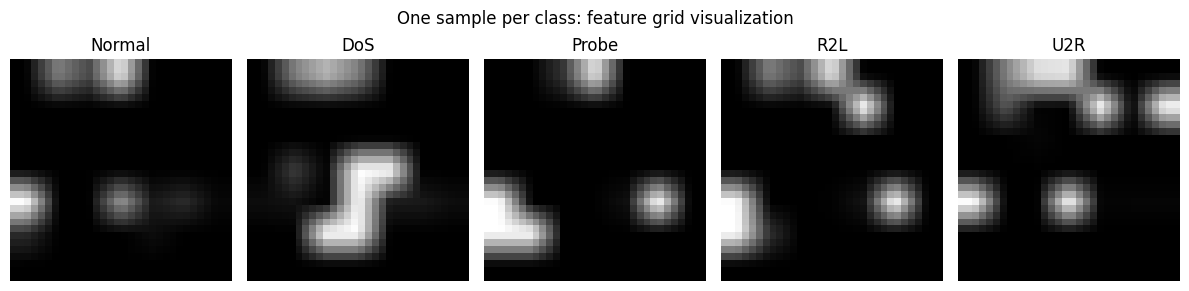

In [ ]:
def features_to_image(X, grid_h=7, grid_w=7):
    """Convert (N, 41) feature array to (N, 3, 32, 32) image tensor."""
    n_cells   = grid_h * grid_w          # 49
    pad_width = n_cells - X.shape[1]     # 49 - 41 = 8

    # Step 1: Pad to 49 features
    X_padded = np.pad(X, ((0, 0), (0, pad_width)), constant_values=0.0)

    # Step 2: Reshape to (N, 1, 7, 7)
    X_grid = X_padded.reshape(-1, 1, grid_h, grid_w)

    # Step 3: Resize to (N, 1, 32, 32)
    X_tensor  = torch.tensor(X_grid, dtype=torch.float32)
    X_resized = F.interpolate(X_tensor, size=(32, 32),
                              mode='bilinear', align_corners=False)

    # Step 4: Repeat to 3 channels → (N, 3, 32, 32)
    X_rgb = X_resized.repeat(1, 3, 1, 1)
    return X_rgb

# Convert training and test sets
X_train_img = features_to_image(X_train)
X_test_img  = features_to_image(X_test)

print("X_train_img shape:", X_train_img.shape)  # (N, 3, 32, 32)
print("X_test_img  shape:", X_test_img.shape)

# Visualize one sample image per class
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, class_id in enumerate(range(5)):
    idx = np.where(y_train == class_id)[0][0]
    img = X_train_img[idx, 0].numpy()   # take channel 0
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(class_order[class_id])
    axes[i].axis('off')
plt.suptitle("One sample per class: feature grid visualization")
plt.tight_layout()
plt.show()


## Section 7 — Shared Training Utilities

We define one `train_one_epoch` function used by all CNN experiments, and create the shared test DataLoader used by every model's evaluation.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)   # should say: cuda

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Run one full pass over the training data. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == y_batch).sum().item()
        total      += y_batch.size(0)
    return total_loss / len(loader), correct / total

# Shared test DataLoader — used by ALL model evaluations below
test_loader = DataLoader(
    TensorDataset(X_test_img, torch.tensor(y_test, dtype=torch.long)),
    batch_size=256, shuffle=False
)

print("Shared utilities ready!")


Using device: cuda
Shared utilities ready!


## Section 8 — ResNet-18 + Class Weights

**Why class weights?** R2L and U2R appear very rarely in training data. Without correction, the model learns to ignore them. Class weights penalize mistakes on rare classes more heavily during the loss calculation.

**Two-stage fine-tuning:**
- **Stage 1 (5 epochs):** Freeze all ResNet layers, train only the final classification layer. This warms up the new layer without destroying pretrained features.
- **Stage 2 (10 epochs):** Unfreeze everything and fine-tune all layers together with a smaller learning rate.

In [ ]:
# ── DataLoader ──
train_loader_cw = DataLoader(
    TensorDataset(X_train_img, torch.tensor(y_train, dtype=torch.long)),
    batch_size=256, shuffle=True
)

# ── Compute balanced class weights ──
# Higher weight = model penalized more for missing that class
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(5),
    y=y_train
)
print("Class weights:", np.round(class_weights, 2))
# Normal ~0.37, DoS ~0.55, Probe ~2.2, R2L ~25, U2R ~485

cw_tensor    = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion_cw = nn.CrossEntropyLoss(weight=cw_tensor)

# ── Fresh ResNet-18 ──
model_cw = models.resnet18(weights='IMAGENET1K_V1')
model_cw.fc = nn.Linear(512, 5)   # replace final layer: 1000 classes → 5
model_cw = model_cw.to(device)

# ── Stage 1: freeze all, train final layer only ──
for p in model_cw.parameters():
    p.requires_grad = False
model_cw.fc.weight.requires_grad = True
model_cw.fc.bias.requires_grad   = True

optimizer_cw = optim.Adam(model_cw.fc.parameters(), lr=0.001)

print("\nStage 1 — final layer only (5 epochs)...")
for epoch in range(5):
    loss, acc = train_one_epoch(model_cw, train_loader_cw,
                                optimizer_cw, criterion_cw, device)
    print(f"  Epoch {epoch+1}/5  Loss: {loss:.4f} | Acc: {acc:.4f}")

# ── Stage 2: unfreeze everything, fine-tune all layers ──
for p in model_cw.parameters():
    p.requires_grad = True

optimizer_cw = optim.Adam(model_cw.parameters(), lr=0.0001)  # smaller lr

print("\nStage 2 — full fine-tuning (10 epochs)...")
for epoch in range(10):
    loss, acc = train_one_epoch(model_cw, train_loader_cw,
                                optimizer_cw, criterion_cw, device)
    print(f"  Epoch {epoch+1}/10  Loss: {loss:.4f} | Acc: {acc:.4f}")

print("\nResNet-18 + Class Weights training complete!")


Class weights: [3.7000e-01 5.5000e-01 2.1600e+00 2.5320e+01 4.8451e+02]

Stage 1 — final layer only (5 epochs)...
  Epoch 1/5  Loss: 0.5043 | Acc: 0.8881
  Epoch 2/5  Loss: 0.2753 | Acc: 0.9278
  Epoch 3/5  Loss: 0.2294 | Acc: 0.9338
  Epoch 4/5  Loss: 0.2046 | Acc: 0.9420
  Epoch 5/5  Loss: 0.1892 | Acc: 0.9427

Stage 2 — full fine-tuning (10 epochs)...
  Epoch 1/10  Loss: 0.3017 | Acc: 0.9394
  Epoch 2/10  Loss: 0.1948 | Acc: 0.9530
  Epoch 3/10  Loss: 0.1311 | Acc: 0.9607
  Epoch 4/10  Loss: 0.1585 | Acc: 0.9589
  Epoch 5/10  Loss: 0.1383 | Acc: 0.9641
  Epoch 6/10  Loss: 0.1298 | Acc: 0.9676
  Epoch 7/10  Loss: 0.1339 | Acc: 0.9648
  Epoch 8/10  Loss: 0.1104 | Acc: 0.9671
  Epoch 9/10  Loss: 0.0987 | Acc: 0.9757
  Epoch 10/10  Loss: 0.0739 | Acc: 0.9784

ResNet-18 + Class Weights training complete!


In [ ]:
# ── Evaluate ResNet-18 + Class Weights ──
model_cw.eval()
all_preds_cw, all_labels_cw = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_cw(X_batch)
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds_cw.extend(preds)
        all_labels_cw.extend(y_batch.numpy())

print("=== ResNet-18 + Class Weights ===")
print(classification_report(all_labels_cw, all_preds_cw, target_names=class_order))


=== ResNet-18 + Class Weights ===
              precision    recall  f1-score   support

      Normal       0.83      0.95      0.89      9711
         DoS       0.99      0.93      0.96      5741
       Probe       0.76      0.75      0.75      1106
         R2L       0.91      0.33      0.48      2199
         U2R       0.07      0.62      0.13        37

    accuracy                           0.86     18794
   macro avg       0.71      0.72      0.64     18794
weighted avg       0.88      0.86      0.85     18794



## Section 9 — ResNet-18 + SMOTE

**Why SMOTE?** Instead of re-weighting the loss, SMOTE (Synthetic Minority Oversampling Technique) synthetically generates new examples of rare classes so that the training set becomes balanced.

**Important:** SMOTE is applied to the raw 41-feature vectors, not to the images. We then convert the resampled data to images afterward.

**Note:** As our professor warned, SMOTE can hurt performance on very rare classes (R2L, U2R) because synthesizing realistic rare examples is hard. We include it as a comparison.

In [ ]:
# ── Apply SMOTE to raw features (before image conversion) ──
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class counts BEFORE SMOTE:")
for name, i in label_map.items():
    print(f"  {name:8s}: {(y_train == i).sum():,}")

print("\nClass counts AFTER SMOTE:")
for name, i in label_map.items():
    print(f"  {name:8s}: {(y_train_smote == i).sum():,}")

# ── Convert SMOTE data to images ──
X_train_smote_img = features_to_image(X_train_smote)

# ── DataLoader for SMOTE data ──
train_loader_smote = DataLoader(
    TensorDataset(X_train_smote_img,
                  torch.tensor(y_train_smote, dtype=torch.long)),
    batch_size=256, shuffle=True
)

# No class weights — SMOTE already balanced the data
criterion_smote = nn.CrossEntropyLoss()

# ── Fresh ResNet-18 ──
model_smote = models.resnet18(weights='IMAGENET1K_V1')
model_smote.fc = nn.Linear(512, 5)
model_smote = model_smote.to(device)

# ── Stage 1: freeze all, train final layer only ──
for p in model_smote.parameters():
    p.requires_grad = False
model_smote.fc.weight.requires_grad = True
model_smote.fc.bias.requires_grad   = True

optimizer_smote = optim.Adam(model_smote.fc.parameters(), lr=0.001)

print("\nStage 1 — final layer only (5 epochs)...")
for epoch in range(5):
    loss, acc = train_one_epoch(model_smote, train_loader_smote,
                                optimizer_smote, criterion_smote, device)
    print(f"  Epoch {epoch+1}/5  Loss: {loss:.4f} | Acc: {acc:.4f}")

# ── Stage 2: unfreeze everything ──
for p in model_smote.parameters():
    p.requires_grad = True

optimizer_smote = optim.Adam(model_smote.parameters(), lr=0.0001)

print("\nStage 2 — full fine-tuning (10 epochs)...")
for epoch in range(10):
    loss, acc = train_one_epoch(model_smote, train_loader_smote,
                                optimizer_smote, criterion_smote, device)
    print(f"  Epoch {epoch+1}/10  Loss: {loss:.4f} | Acc: {acc:.4f}")

print("\nResNet-18 + SMOTE training complete!")


Class counts BEFORE SMOTE:
  Normal  : 67,343
  DoS     : 45,927
  Probe   : 11,656
  R2L     : 995
  U2R     : 52

Class counts AFTER SMOTE:
  Normal  : 67,343
  DoS     : 67,343
  Probe   : 67,343
  R2L     : 67,343
  U2R     : 67,343

Stage 1 — final layer only (5 epochs)...
  Epoch 1/5  Loss: 0.2244 | Acc: 0.9311
  Epoch 2/5  Loss: 0.1413 | Acc: 0.9547
  Epoch 3/5  Loss: 0.1293 | Acc: 0.9585
  Epoch 4/5  Loss: 0.1225 | Acc: 0.9605
  Epoch 5/5  Loss: 0.1182 | Acc: 0.9618

Stage 2 — full fine-tuning (10 epochs)...
  Epoch 1/10  Loss: 0.0535 | Acc: 0.9825
  Epoch 2/10  Loss: 0.0298 | Acc: 0.9904
  Epoch 3/10  Loss: 0.0249 | Acc: 0.9919
  Epoch 4/10  Loss: 0.0213 | Acc: 0.9928
  Epoch 5/10  Loss: 0.0194 | Acc: 0.9936
  Epoch 6/10  Loss: 0.0171 | Acc: 0.9945
  Epoch 7/10  Loss: 0.0158 | Acc: 0.9950
  Epoch 8/10  Loss: 0.0143 | Acc: 0.9954
  Epoch 9/10  Loss: 0.0131 | Acc: 0.9960
  Epoch 10/10  Loss: 0.0130 | Acc: 0.9960

ResNet-18 + SMOTE training complete!


In [ ]:
# ── Evaluate ResNet-18 + SMOTE ──
model_smote.eval()
all_preds_smote, all_labels_smote = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_smote(X_batch)
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds_smote.extend(preds)
        all_labels_smote.extend(y_batch.numpy())

print("=== ResNet-18 + SMOTE ===")
print(classification_report(all_labels_smote, all_preds_smote, target_names=class_order))


=== ResNet-18 + SMOTE ===
              precision    recall  f1-score   support

      Normal       0.83      0.97      0.90      9711
         DoS       0.99      0.97      0.98      5741
       Probe       0.74      0.76      0.75      1106
         R2L       0.98      0.26      0.41      2199
         U2R       0.26      0.32      0.29        37

    accuracy                           0.87     18794
   macro avg       0.76      0.66      0.66     18794
weighted avg       0.89      0.87      0.85     18794



## Section 10 — ResNet-18 + SMOTE + Gentle Class Weights

**Why combine both?** SMOTE balances the raw counts, but very rare classes (R2L, U2R) can still be underweighted after resampling. Adding *gentle* class weights on top gives them a small extra nudge without over-penalizing the model.

We reuse `X_train_smote_img` and `train_loader_smote` from Section 9 — no need to redo SMOTE.

**Gentle weights** = [1.0, 1.0, 1.0, 2.0, 3.0] — small boosts only for R2L and U2R.

In [ ]:
# Reuse SMOTE data from Section 9 — no need to redo SMOTE!
# train_loader_smote and X_train_smote_img already exist

# Gentle weights: small nudge for rare classes on top of SMOTE balancing
gentle_weights = torch.tensor(
    [1.0, 1.0, 1.0, 2.0, 3.0],   # Normal, DoS, Probe, R2L, U2R
    dtype=torch.float32
).to(device)
criterion_combined = nn.CrossEntropyLoss(weight=gentle_weights)

# Fresh ResNet-18
model_combined = models.resnet18(weights='IMAGENET1K_V1')
model_combined.fc = nn.Linear(512, 5)
model_combined = model_combined.to(device)

# Stage 1: freeze all, train final layer only
for p in model_combined.parameters():
    p.requires_grad = False
model_combined.fc.weight.requires_grad = True
model_combined.fc.bias.requires_grad   = True

optimizer_combined = optim.Adam(model_combined.fc.parameters(), lr=0.001)

print("Stage 1 — final layer only (5 epochs)...")
for epoch in range(5):
    loss, acc = train_one_epoch(model_combined, train_loader_smote,
                                optimizer_combined, criterion_combined, device)
    print(f"  Epoch {epoch+1}/5  Loss: {loss:.4f} | Acc: {acc:.4f}")

# Stage 2: unfreeze everything
for p in model_combined.parameters():
    p.requires_grad = True

optimizer_combined = optim.Adam(model_combined.parameters(), lr=0.0001)

print("\nStage 2 — full fine-tuning (10 epochs)...")
for epoch in range(10):
    loss, acc = train_one_epoch(model_combined, train_loader_smote,
                                optimizer_combined, criterion_combined, device)
    print(f"  Epoch {epoch+1}/10  Loss: {loss:.4f} | Acc: {acc:.4f}")

print("\nResNet-18 + SMOTE + Gentle Weights training complete!")


Stage 1 — final layer only (5 epochs)...
  Epoch 1/5  Loss: 0.2160 | Acc: 0.9232
  Epoch 2/5  Loss: 0.1329 | Acc: 0.9526
  Epoch 3/5  Loss: 0.1193 | Acc: 0.9573
  Epoch 4/5  Loss: 0.1154 | Acc: 0.9586
  Epoch 5/5  Loss: 0.1111 | Acc: 0.9598

Stage 2 — full fine-tuning (10 epochs)...
  Epoch 1/10  Loss: 0.0549 | Acc: 0.9820
  Epoch 2/10  Loss: 0.0296 | Acc: 0.9904
  Epoch 3/10  Loss: 0.0270 | Acc: 0.9913
  Epoch 4/10  Loss: 0.0220 | Acc: 0.9929
  Epoch 5/10  Loss: 0.0201 | Acc: 0.9935
  Epoch 6/10  Loss: 0.0183 | Acc: 0.9941
  Epoch 7/10  Loss: 0.0173 | Acc: 0.9945
  Epoch 8/10  Loss: 0.0160 | Acc: 0.9950
  Epoch 9/10  Loss: 0.0154 | Acc: 0.9952
  Epoch 10/10  Loss: 0.0133 | Acc: 0.9956

ResNet-18 + SMOTE + Gentle Weights training complete!


In [ ]:
# Evaluate ResNet-18 + SMOTE + Gentle Weights
model_combined.eval()
all_preds_combined, all_labels_combined = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_combined(X_batch)
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds_combined.extend(preds)
        all_labels_combined.extend(y_batch.numpy())

print("=== ResNet-18 + SMOTE + Gentle Weights ===")
print(classification_report(all_labels_combined, all_preds_combined,
      target_names=class_order))


=== ResNet-18 + SMOTE + Gentle Weights ===
              precision    recall  f1-score   support

      Normal       0.81      0.97      0.89      9711
         DoS       0.99      0.97      0.98      5741
       Probe       0.77      0.75      0.76      1106
         R2L       0.96      0.21      0.34      2199
         U2R       0.34      0.35      0.35        37

    accuracy                           0.87     18794
   macro avg       0.77      0.65      0.66     18794
weighted avg       0.88      0.87      0.84     18794



## Section 11 — 4-Class Experiment: ResNet-18 + SMOTE + Gentle Weights

**Why 4 classes?** R2L has only 995 training examples and U2R has just 52 — too few for SMOTE to synthesize realistic samples. By merging them into a single "Others" class, we give the model ~1,047 combined examples to work with, which is a much better base for SMOTE.

**New class mapping:**
- Normal, DoS, Probe → same as before
- R2L + U2R → **Others**

We also evaluate on **KDDTest-21**, the harder test set, to check generalization.

This is our stretch goal experiment from the proposal.

In [ ]:
# New 4-class label mapping
attack_map_4 = {
    'normal': 'Normal',
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    # R2L + U2R merged into Others
    'ftp_write':'Others','guess_passwd':'Others','imap':'Others','multihop':'Others',
    'phf':'Others','spy':'Others','warezclient':'Others','warezmaster':'Others',
    'buffer_overflow':'Others','loadmodule':'Others','perl':'Others','rootkit':'Others'
}
class_order_4 = ['Normal', 'DoS', 'Probe', 'Others']
label_map_4   = {c: i for i, c in enumerate(class_order_4)}

# Load fresh copies of the data
train_df4  = pd.read_csv('KDDTrain+.txt',  names=col_names)
test_df4   = pd.read_csv('KDDTest+.txt',   names=col_names)
test21_df4 = pd.read_csv('KDDTest-21.txt', names=col_names)

# Apply 4-class map
for df in [train_df4, test_df4, test21_df4]:
    df['attack_class'] = df['label'].map(attack_map_4)

train_df4  = train_df4.dropna(subset=['attack_class'])
test_df4   = test_df4.dropna(subset=['attack_class'])
test21_df4 = test21_df4.dropna(subset=['attack_class'])

# Encode categoricals (fit on train only)
le_p4 = LabelEncoder()
le_s4 = LabelEncoder()
le_f4 = LabelEncoder()

train_df4['protocol_type'] = le_p4.fit_transform(train_df4['protocol_type'])
train_df4['service']       = le_s4.fit_transform(train_df4['service'])
train_df4['flag']          = le_f4.fit_transform(train_df4['flag'])

for df in [test_df4, test21_df4]:
    df['protocol_type'] = le_p4.transform(df['protocol_type'])
    df['service']       = le_s4.transform(df['service'])
    df['flag']          = le_f4.transform(df['flag'])

# Extract features and labels
X_train4 = train_df4[feature_cols].values
X_test4  = test_df4[feature_cols].values
X_test21 = test21_df4[feature_cols].values

y_train4  = train_df4['attack_class'].map(label_map_4).values
y_test4   = test_df4['attack_class'].map(label_map_4).values
y_test21  = test21_df4['attack_class'].map(label_map_4).values

# Normalize (fit on train only)
scaler4  = MinMaxScaler()
X_train4 = scaler4.fit_transform(X_train4)
X_test4  = scaler4.transform(X_test4)
X_test21 = scaler4.transform(X_test21)

print("4-class distribution in training set:")
for c, i in label_map_4.items():
    print(f"  {c:8s}: {(y_train4 == i).sum():,}")


4-class distribution in training set:
  Normal  : 67,343
  DoS     : 45,927
  Probe   : 11,656
  Others  : 1,047


In [ ]:
# Apply SMOTE to 4-class data
# 'Others' now has ~1,047 examples — much better base than 52 (U2R alone)
smote4 = SMOTE(random_state=42)
X_train4_smote, y_train4_smote = smote4.fit_resample(X_train4, y_train4)

print("After SMOTE (4-class):")
for c, i in label_map_4.items():
    print(f"  {c:8s}: {(y_train4_smote == i).sum():,}")

# Convert to images
X_train4_smote_img = features_to_image(X_train4_smote)
X_test4_img        = features_to_image(X_test4)
X_test21_img       = features_to_image(X_test21)

# DataLoader
train_loader4 = DataLoader(
    TensorDataset(X_train4_smote_img,
                  torch.tensor(y_train4_smote, dtype=torch.long)),
    batch_size=256, shuffle=True
)

# Shared test loaders for 4-class
test_loader4 = DataLoader(
    TensorDataset(X_test4_img, torch.tensor(y_test4, dtype=torch.long)),
    batch_size=256, shuffle=False
)
test21_loader4 = DataLoader(
    TensorDataset(X_test21_img, torch.tensor(y_test21, dtype=torch.long)),
    batch_size=256, shuffle=False
)

# Gentle weights for 4 classes
gentle_weights4 = torch.tensor(
    [1.0, 1.0, 1.0, 3.0],   # slight boost for Others
    dtype=torch.float32
).to(device)
criterion4 = nn.CrossEntropyLoss(weight=gentle_weights4)

# Fresh ResNet-18 with 4-class output
model4 = models.resnet18(weights='IMAGENET1K_V1')
model4.fc = nn.Linear(512, 4)   # 4 classes, not 5!
model4 = model4.to(device)

# Stage 1
for p in model4.parameters():
    p.requires_grad = False
model4.fc.weight.requires_grad = True
model4.fc.bias.requires_grad   = True
optimizer4 = optim.Adam(model4.fc.parameters(), lr=0.001)

print("\nStage 1 — final layer only (5 epochs)...")
for epoch in range(5):
    loss, acc = train_one_epoch(model4, train_loader4,
                                optimizer4, criterion4, device)
    print(f"  Epoch {epoch+1}/5  Loss: {loss:.4f} | Acc: {acc:.4f}")

# Stage 2
for p in model4.parameters():
    p.requires_grad = True
optimizer4 = optim.Adam(model4.parameters(), lr=0.0001)

print("\nStage 2 — full fine-tuning (10 epochs)...")
for epoch in range(10):
    loss, acc = train_one_epoch(model4, train_loader4,
                                optimizer4, criterion4, device)
    print(f"  Epoch {epoch+1}/10  Loss: {loss:.4f} | Acc: {acc:.4f}")

print("\n4-class model training complete!")


After SMOTE (4-class):
  Normal  : 67,343
  DoS     : 67,343
  Probe   : 67,343
  Others  : 67,343

Stage 1 — final layer only (5 epochs)...
  Epoch 1/5  Loss: 0.1911 | Acc: 0.9238
  Epoch 2/5  Loss: 0.1143 | Acc: 0.9552
  Epoch 3/5  Loss: 0.1034 | Acc: 0.9600
  Epoch 4/5  Loss: 0.0976 | Acc: 0.9619
  Epoch 5/5  Loss: 0.0952 | Acc: 0.9628

Stage 2 — full fine-tuning (10 epochs)...
  Epoch 1/10  Loss: 0.0381 | Acc: 0.9859
  Epoch 2/10  Loss: 0.0196 | Acc: 0.9923
  Epoch 3/10  Loss: 0.0177 | Acc: 0.9930
  Epoch 4/10  Loss: 0.0142 | Acc: 0.9944
  Epoch 5/10  Loss: 0.0123 | Acc: 0.9953
  Epoch 6/10  Loss: 0.0119 | Acc: 0.9953
  Epoch 7/10  Loss: 0.0113 | Acc: 0.9956
  Epoch 8/10  Loss: 0.0096 | Acc: 0.9962
  Epoch 9/10  Loss: 0.0094 | Acc: 0.9962
  Epoch 10/10  Loss: 0.0089 | Acc: 0.9964

4-class model training complete!


In [ ]:
# Evaluate 4-class model on KDDTest+ (standard)
model4.eval()
all_preds4, all_labels4 = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader4:
        X_batch = X_batch.to(device)
        preds   = model4(X_batch).argmax(1).cpu().numpy()
        all_preds4.extend(preds)
        all_labels4.extend(y_batch.numpy())

print("=== 4-Class ResNet-18 — KDDTest+ (Standard) ===")
print(classification_report(all_labels4, all_preds4, target_names=class_order_4))

# Evaluate on KDDTest-21 (harder — stretch goal)
all_preds21, all_labels21 = [], []

with torch.no_grad():
    for X_batch, y_batch in test21_loader4:
        X_batch = X_batch.to(device)
        preds   = model4(X_batch).argmax(1).cpu().numpy()
        all_preds21.extend(preds)
        all_labels21.extend(y_batch.numpy())

print("=== 4-Class ResNet-18 — KDDTest-21 (Harder) ===")
print(classification_report(all_labels21, all_preds21, target_names=class_order_4))


=== 4-Class ResNet-18 — KDDTest+ (Standard) ===
              precision    recall  f1-score   support

      Normal       0.81      0.98      0.89      9711
         DoS       0.99      0.96      0.98      5741
       Probe       0.80      0.73      0.77      1106
      Others       0.94      0.19      0.32      2236

    accuracy                           0.87     18794
   macro avg       0.89      0.72      0.74     18794
weighted avg       0.88      0.87      0.84     18794

=== 4-Class ResNet-18 — KDDTest-21 (Harder) ===
              precision    recall  f1-score   support

      Normal       0.47      0.91      0.62      2152
         DoS       0.98      0.94      0.96      2625
       Probe       0.84      0.73      0.78      1097
      Others       0.97      0.19      0.32      2236

    accuracy                           0.70      8110
   macro avg       0.81      0.69      0.67      8110
weighted avg       0.82      0.70      0.67      8110



## Section 12 — Confusion Matrices

A confusion matrix shows us exactly where each model makes mistakes. Each row is the **true class**, each column is the **predicted class**. We normalize each row to show percentages, so the diagonal tells us the recall for each class.

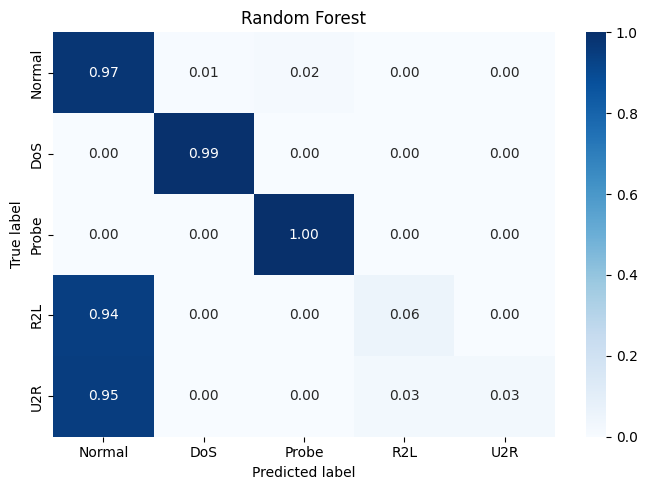

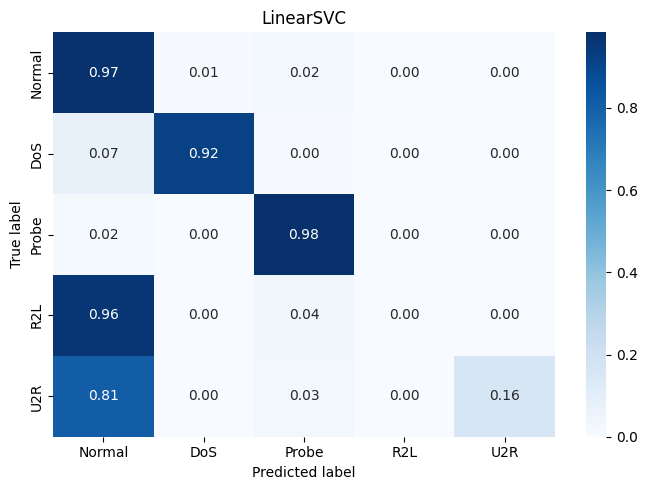

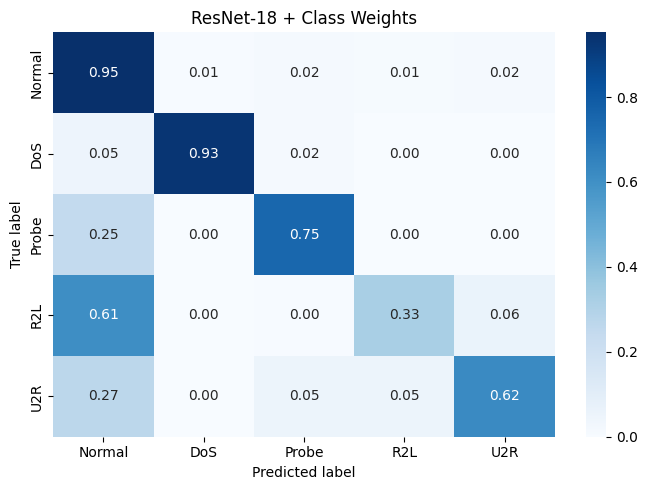

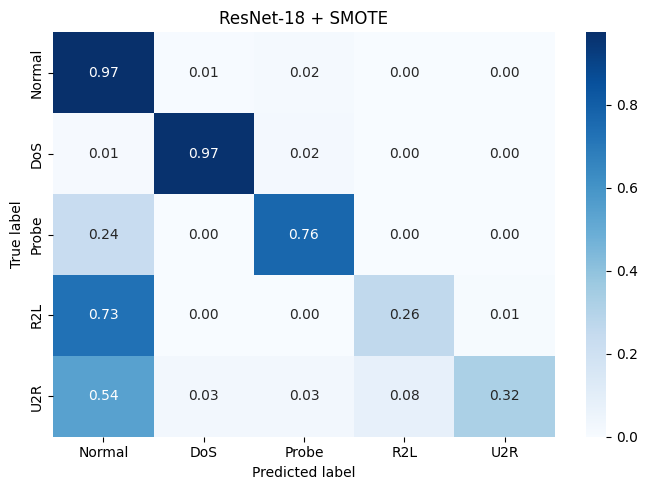

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, class_names):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

plot_confusion_matrix(y_test,          y_pred_rf,
                      "Random Forest",              class_order)
plot_confusion_matrix(y_test,          y_pred_svm,
                      "LinearSVC",                  class_order)
plot_confusion_matrix(all_labels_cw,   all_preds_cw,
                      "ResNet-18 + Class Weights",  class_order)
plot_confusion_matrix(all_labels_smote, all_preds_smote,
                      "ResNet-18 + SMOTE",          class_order)


## Section 13 — Precision-Recall Curves

Precision-Recall curves are more informative than ROC curves when classes are heavily imbalanced. We focus on **R2L** and **U2R** — the two rarest and most dangerous attack types.

- **High precision** = when the model says it's R2L, it's usually right
- **High recall** = the model catches most actual R2L attacks
- **AP (Average Precision)** = single number summarizing the whole curve; higher is better

In [ ]:
# ── Get probability scores for each model ──
from sklearn.calibration import CalibratedClassifierCV

# Random Forest — has predict_proba natively
y_prob_rf = rf.predict_proba(X_test)

# LinearSVC — doesn't output probabilities, so we calibrate it first
svm_calibrated = CalibratedClassifierCV(svm, cv='prefit')
svm_calibrated.fit(X_train, y_train)
y_prob_svm = svm_calibrated.predict_proba(X_test)

# ResNet-18 + Class Weights
model_cw.eval()
all_probs_cw = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = torch.softmax(model_cw(X_batch.to(device)), dim=1).cpu().numpy()
        all_probs_cw.extend(probs)
y_prob_cw = np.array(all_probs_cw)

# ResNet-18 + SMOTE
model_smote.eval()
all_probs_smote = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = torch.softmax(model_smote(X_batch.to(device)), dim=1).cpu().numpy()
        all_probs_smote.extend(probs)
y_prob_smote_pr = np.array(all_probs_smote)

print("All probability scores ready!")


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


All probability scores ready!


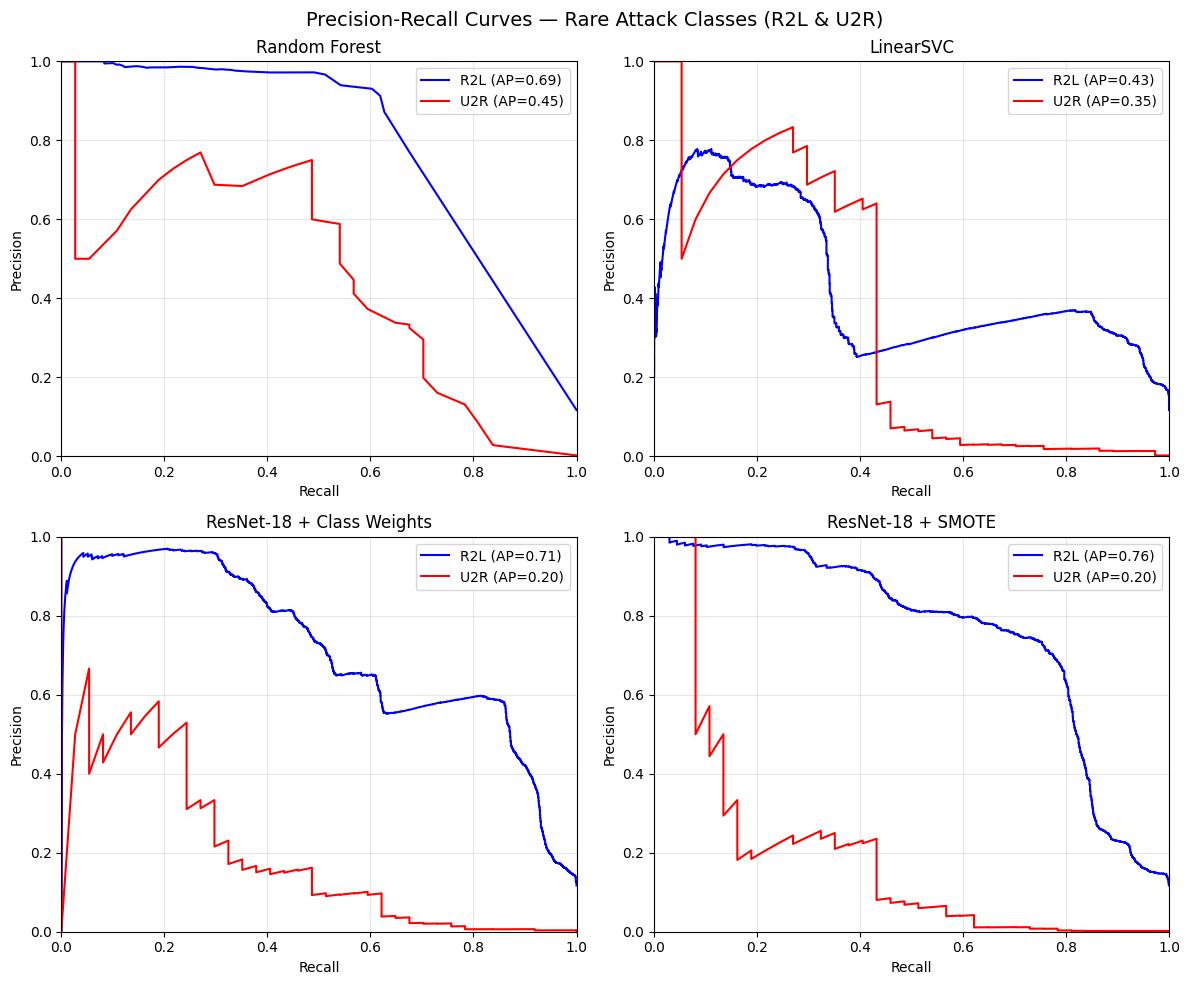

In [ ]:
# ── Plot Precision-Recall curves ──
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, average_precision_score,
                              f1_score)
from imblearn.over_sampling import SMOTE
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Precision-Recall Curves — Rare Attack Classes (R2L & U2R)", fontsize=14)

models_info = [
    ("Random Forest",             y_prob_rf),
    ("LinearSVC",                 y_prob_svm),
    ("ResNet-18 + Class Weights", y_prob_cw),
    ("ResNet-18 + SMOTE",         y_prob_smote_pr),
]

for ax, (name, y_prob) in zip(axes.flatten(), models_info):
    for class_idx, class_name, color in [
        (3, 'R2L', 'blue'),
        (4, 'U2R', 'red'),
    ]:
        precision, recall, _ = precision_recall_curve(
            y_test_bin[:, class_idx], y_prob[:, class_idx])
        ap = average_precision_score(
            y_test_bin[:, class_idx], y_prob[:, class_idx])
        ax.plot(recall, precision, color=color,
                label=f'{class_name} (AP={ap:.2f})')

    ax.set_title(name)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()


## Section 14 — Results Summary

Final comparison of macro F1 scores across all models.

In [ ]:
from sklearn.metrics import f1_score

results_5class = {
    "Random Forest":                   f1_score(y_test, y_pred_rf,           average='macro'),
    "LinearSVC":                       f1_score(y_test, y_pred_svm,          average='macro'),
    "ResNet-18 + Class Weights":       f1_score(all_labels_cw,       all_preds_cw,       average='macro'),
    "ResNet-18 + SMOTE":               f1_score(all_labels_smote,    all_preds_smote,    average='macro'),
    "ResNet-18 + SMOTE + Gentle Wts":  f1_score(all_labels_combined, all_preds_combined, average='macro'),
}

results_4class = {
    "4-Class ResNet (KDDTest+)":  f1_score(all_labels4,  all_preds4,  average='macro'),
    "4-Class ResNet (KDDTest-21)": f1_score(all_labels21, all_preds21, average='macro'),
}

print("=" * 50)
print("5-CLASS EXPERIMENTS (KDDTest+)")
print("=" * 50)
print(f"{'Model':<35} {'Macro F1':>10}")
print("-" * 50)
for name, score in results_5class.items():
    print(f"{name:<35} {score:>10.4f}")

print()
print("=" * 50)
print("4-CLASS EXPERIMENT")
print("=" * 50)
print(f"{'Model':<35} {'Macro F1':>10}")
print("-" * 50)
for name, score in results_4class.items():
    print(f"{name:<35} {score:>10.4f}")
print("=" * 50)


5-CLASS EXPERIMENTS (KDDTest+)
Model                                 Macro F1
--------------------------------------------------
Random Forest                           0.5915
LinearSVC                               0.5925
ResNet-18 + Class Weights               0.6407
ResNet-18 + SMOTE                       0.6641
ResNet-18 + SMOTE + Gentle Wts          0.6620

4-CLASS EXPERIMENT
Model                                 Macro F1
--------------------------------------------------
4-Class ResNet (KDDTest+)               0.7376
4-Class ResNet (KDDTest-21)             0.6692


AI Statement:

We used AI to help identifying the issues in our code and help us brainstorm possible solutions. We also use ai to help us learn the code's meaning and the concepts used to train this ml.